In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
sns.set_theme(style="darkgrid")

# Load data
data = pd.read_csv("Linhac24-25_Sportlogiq.csv")

print(data.isnull().sum())
data.head(10)

gameid                                0
opposingteamgoalieoniceid          3266
opposingteamid                        0
playerid                              0
teamgoalieoniceid                  7080
teamid                                0
teaminpossession                  73890
currentpossession                 73890
xg_allattempts                   525454
compiledgametime                      0
eventname                             0
ishomegame                            0
manpowersituation                     0
opposingteamskatersonicecount         0
outcome                               0
period                                0
playerprimaryposition                 0
scoredifferential                     0
teamskatersonicecount                 0
type                                  0
xadjcoord                             0
yadjcoord                             0
dtype: int64


,gameid,opposingteamgoalieoniceid,opposingteamid,playerid,teamgoalieoniceid,teamid,teaminpossession,currentpossession,xg_allattempts,compiledgametime,...,manpowersituation,opposingteamskatersonicecount,outcome,period,playerprimaryposition,scoredifferential,teamskatersonicecount,type,xadjcoord,yadjcoord
0,72393,553243.0,885,489917,172367.0,814,NaN,NaN,NaN,0.000000,...,evenStrength,5,failed,1,F,0,5,none,0.304306,0.251442
1,72393,172367.0,814,435025,553243.0,885,NaN,NaN,NaN,0.000000,...,evenStrength,5,successful,1,F,0,5,recovered,-0.304306,-0.251442
2,72393,172367.0,814,435025,553243.0,885,885.0,0.0,NaN,1.333333,...,evenStrength,5,successful,1,F,0,5,faceoffcontested,0.205826,0.245975
3,72393,553243.0,885,489917,172367.0,814,885.0,0.0,NaN,1.333333,...,evenStrength,5,failed,1,F,0,5,contested,-0.205826,-0.245975
4,72393,172367.0,814,435025,553243.0,885,885.0,0.0,NaN,2.166667,...,evenStrength,5,successful,1,F,0,5,south,3.223473,3.766563
5,72393,172367.0,814,706220,553243.0,885,885.0,0.0,NaN,2.966667,...,evenStrength,5,successful,1,D,0,5,regular,-19.911827,11.310680
6,72393,172367.0,814,706220,553243.0,885,885.0,0.0,NaN,4.466667,...,evenStrength,5,failed,1,D,0,5,north,-7.338295,26.398914
7,72393,553243.0,885,213380,172367.0,814,885.0,0.0,NaN,4.700000,...,evenStrength,5,successful,1,F,0,5,pass,1.813835,-24.897058
8,72393,553243.0,885,213380,172367.0,814,814.0,1.0,NaN,6.033333,...,evenStrength,5,successful,1,F,0,5,none,-17.800873,-40.991177
9,72393,553243.0,885,213380,172367.0,814,814.0,1.0,NaN,6.533333,...,evenStrength,5,successful,1,F,0,5,body,-16.794991,-40.488235


## Check sequence before goal

In [19]:
# Sort the data in a chronoligical order
sorted_data = data.sort_values(by=['gameid', 'compiledgametime']) 
print(sorted_data)

sorted_data['prev_event'] = sorted_data.groupby('gameid')['eventname'].shift(1) #groupby sepereates the data for different games
sorted_data['next_event'] = sorted_data.groupby('gameid')['eventname'].shift(-1)

print(sorted_data[['gameid', 'compiledgametime', 'prev_event', 'eventname', 'next_event']].head(10))


        gameid  opposingteamgoalieoniceid  opposingteamid  playerid  \
216496   60062                   170439.0             855    463268   
216497   60062                   199899.0             634    412148   
216498   60062                   170439.0             855    463268   
216499   60062                   199899.0             634    412148   
216500   60062                   199899.0             634    412148   
...        ...                        ...             ...       ...   
531165   89893                   316087.0             792    133246   
531166   89893                   316087.0             792    133246   
531167   89893                   199899.0             634    823725   
531168   89893                   316087.0             792    133246   
531169   89893                   316087.0             792    133246   

        teamgoalieoniceid  teamid  teaminpossession  currentpossession  \
216496           199899.0     634               NaN                NaN   

In [20]:
# Göra på annat sätt? 
# Kolla på vilka sekvenser som genererar högst expected goals
# Endast kolla på när de är i anfallszon

pp_goals = sorted_data[
    (sorted_data['eventname'] == 'goal') & 
    (sorted_data['manpowersituation'] == 'powerPlay')
].copy()

# Ge varje mål ett unikt ID så vi kan skilja på olika målsekvenser
pp_goals['goal_id'] = range(len(pp_goals))

goal_lookup = pp_goals[['gameid', 'compiledgametime', 'goal_id', 'teamid']].rename(
    columns={'compiledgametime': 'goal_time', 'teamid': 'scoring_teamid'}
)
#Dataframe for only shots

sequences = pd.merge(sorted_data, goal_lookup, on='gameid')

# 4. Filtrera fram händelser som skedde t.ex. 20 sekunder INNAN målet
# Vi vill också ofta (men inte alltid) bara se händelser från det lag som gjorde mål
time_window = 20
pp_sequences = sequences[
    (sequences['compiledgametime'] <= sequences['goal_time']) & 
    (sequences['compiledgametime'] >= sequences['goal_time'] - time_window) &
    (sequences['teamid'] == sequences['scoring_teamid']) # Valfritt: bara det anfallande laget
].copy()

# 5. Resultat: Nu kan du se sekvensen för varje mål
# Vi sorterar så att det blir lättläst
pp_sequences = pp_sequences.sort_values(by=['goal_id', 'compiledgametime'])

# Exempel: Visa sekvensen för det första PP-målet
print(pp_sequences[pp_sequences['goal_id'] == 0][['compiledgametime', 'eventname', 'type', 'xadjcoord', 'yadjcoord']])


      compiledgametime        eventname                           type  \
2340           1177.08             pass                       eastwest   
2342           1178.12        reception                        regular   
2344           1178.60             pass                       eastwest   
2346           1179.76        reception                        regular   
2348           1180.52           dumpin                           dump   
2356           1185.72              lpr                         opdump   
2358           1186.96             pass                       eastwest   
2360           1187.72        reception                        regular   
2362           1188.44             pass                       eastwest   
2364           1189.56        reception                        regular   
2366           1190.24            carry                           none   
2368           1190.24  controlledentry  carrywithshotonnetandslotshot   
2372           1190.88             pas

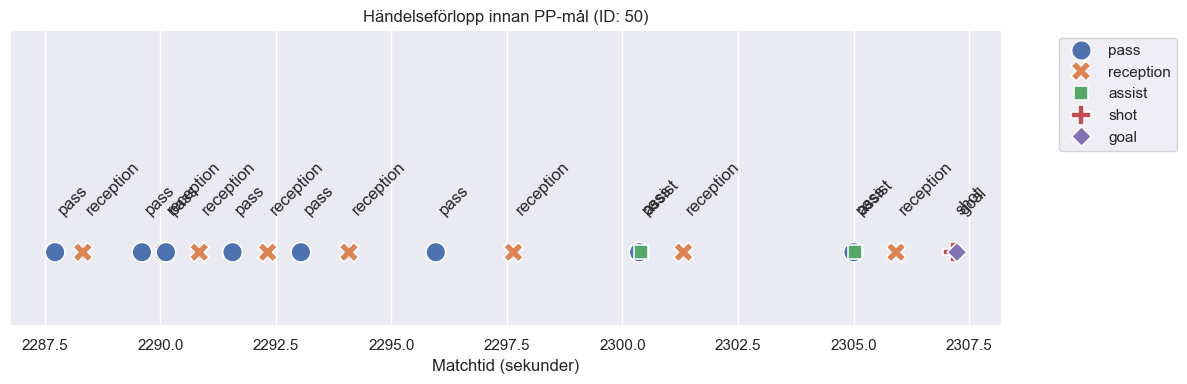

In [21]:
# Välj ett specifikt mål att visualisera (t.ex. mål_id 0)
goal_id_to_plot = 50
single_seq = pp_sequences[pp_sequences['goal_id'] == goal_id_to_plot]

plt.figure(figsize=(12, 4))
sns.scatterplot(data=single_seq, x='compiledgametime', y=[1]*len(single_seq), 
                hue='eventname', s=200, style='eventname')

# Lägg till textetiketter för varje händelse
for i, row in single_seq.iterrows():
    plt.text(row['compiledgametime'], 1.05, row['eventname'], 
             rotation=45, horizontalalignment='left')

plt.title(f'Händelseförlopp innan PP-mål (ID: {goal_id_to_plot})')
plt.xlabel('Matchtid (sekunder)')
plt.yticks([]) # Ta bort y-axeln då den inte behövs
plt.ylim(0.9, 1.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

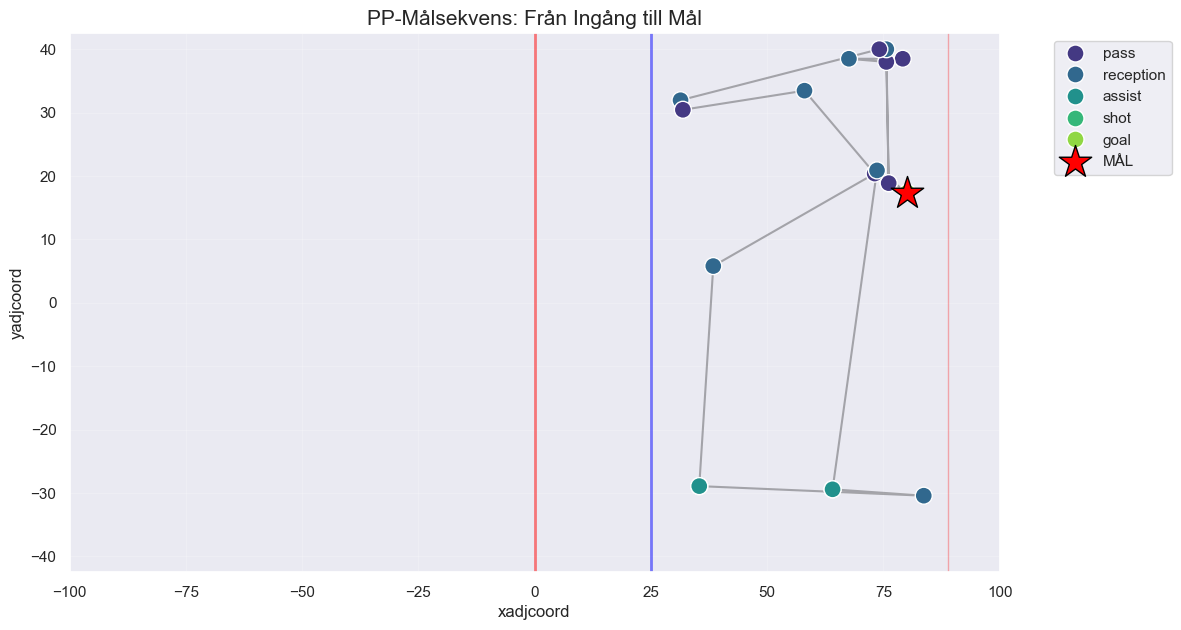

In [22]:


plt.figure(figsize=(12, 7))

# Rita rinken (Anfallszonen är till höger, x > 25)
# Blålinjen är vid x = 25, Mittlinjen vid x = 0, Mållinjen vid x = 89
plt.axvline(0, color='red', linewidth=2, alpha=0.5)  # Mittlinje
plt.axvline(25, color='blue', linewidth=2, alpha=0.5) # Blålinje
plt.axvline(89, color='red', linewidth=1, alpha=0.3)  # Mållinje

# Plotta puckvägen
plt.plot(single_seq['xadjcoord'], single_seq['yadjcoord'], 
         color='black', linestyle='-', alpha=0.3, zorder=1)

# Plotta händelser
sns.scatterplot(data=single_seq, x='xadjcoord', y='yadjcoord', 
                hue='eventname', s=150, zorder=3, palette='viridis')

# Markera målet extra tydligt
goal_row = single_seq[single_seq['eventname'] == 'goal']
if not goal_row.empty:
    plt.scatter(goal_row['xadjcoord'], goal_row['yadjcoord'], 
                color='red', marker='*', s=600, label='MÅL', zorder=5, edgecolors='black')

# Sätt gränserna för anfallszonen (+ lite av mittzon)
plt.xlim(-100, 100) 
plt.ylim(-42.5, 42.5)

plt.title('PP-Målsekvens: Från Ingång till Mål' , fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

### Cluster different sequences

Genomsnittliga egenskaper per kluster:
         x_mean  x_std  x_min  y_mean  y_std  num_passes  num_carries  \
cluster                                                                 
0         59.49  20.94  25.64    1.45  23.26        5.79         0.11   
1         23.66  50.02 -73.59   -0.67  22.03        5.07         1.82   
2         59.37  19.63  27.00   -2.54  21.02        8.64         0.16   

         total_events  duration  
cluster                          
0               19.24     18.87  
1               21.01     17.95  
2               25.00     18.97  


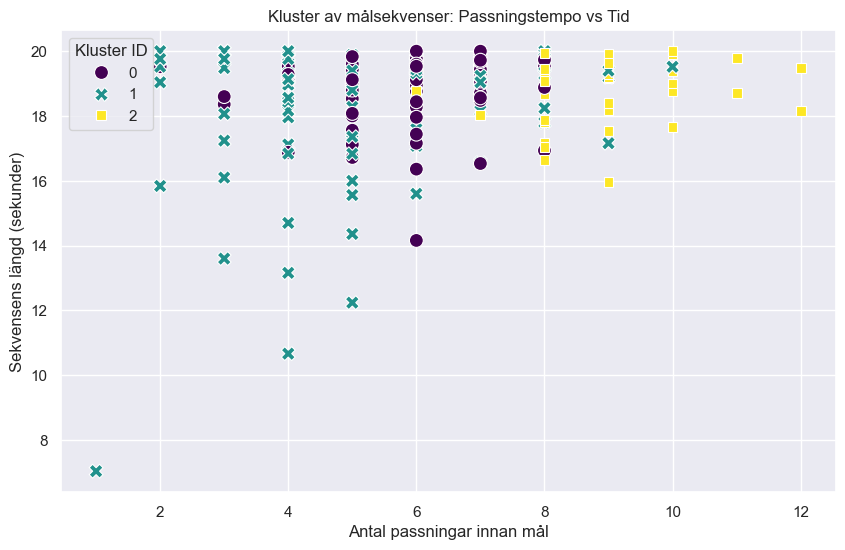

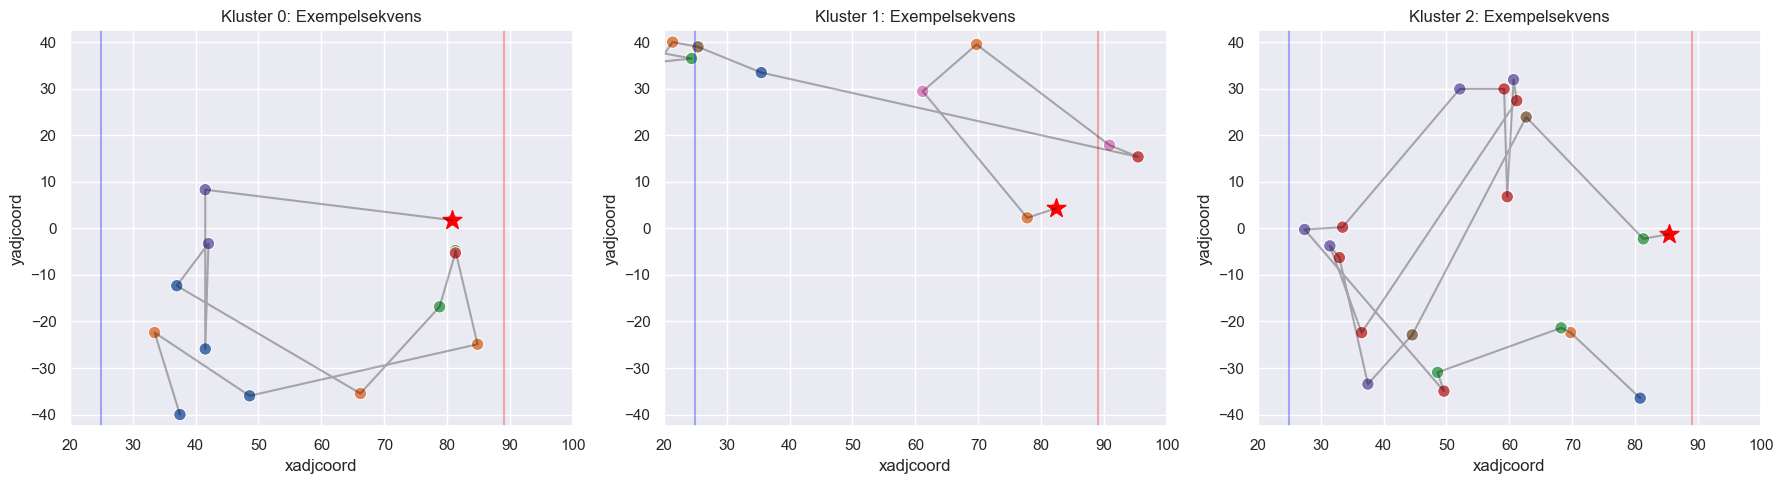

In [23]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def create_cluster_features(df_sequences):
    # Vi grupperar på goal_id för att sammanfatta vad som hände innan målet
    features = df_sequences.groupby('goal_id').agg({
        'xadjcoord': ['mean', 'std', 'min'], # Position i djupled
        'yadjcoord': ['mean', 'std'],        # Position i sidled (spridning)
        'eventname': [
            lambda x: (x == 'pass').sum(),   # Antal passningar i sekvensen
            lambda x: (x == 'carry').sum(),  # Antal pucktransporter
            'count'                          # Totala antalet händelser
        ],
        'compiledgametime': lambda x: x.max() - x.min() # Sekvensens varaktighet i sekunder
    })

    # Platta till kolumnnamnen för enklare hantering
    features.columns = [
        'x_mean', 'x_std', 'x_min', 
        'y_mean', 'y_std', 
        'num_passes', 'num_carries', 'total_events', 
        'duration'
    ]
    
    # Hantera eventuella NaN (t.ex. om std inte kan beräknas på en händelse)
    return features.fillna(0)

# Skapa feature-matrisen
features_df = create_cluster_features(pp_sequences)

# ==========================================
# 2. PREPROCESSING OCH KLUSTERING
# ==========================================

# Skala datan (Viktigt! K-Means baseras på avstånd, så alla enheter måste vara jämförbara)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df)

# Vi väljer 3 kluster som utgångspunkt (t.ex. "Direktavslut", "Långt tryck", "Kontring/Ingång")
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
features_df['cluster'] = kmeans.fit_predict(scaled_features)

# Koppla tillbaka kluster-ID till den ursprungliga sekvens-datan
pp_sequences = pp_sequences.merge(features_df[['cluster']], on='goal_id', how='left')

# ==========================================
# 3. ANALYS OCH VISUALISERING AV KLUSTER
# ==========================================

# Kolla genomsnittet för varje kluster för att tolka dem
cluster_interpretation = features_df.groupby('cluster').mean()
print("Genomsnittliga egenskaper per kluster:")
print(cluster_interpretation.round(2))

# Visualisera klustren i en Scatterplot (t.ex. Antal passningar vs Varaktighet)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=features_df, 
    x='num_passes', 
    y='duration', 
    hue='cluster', 
    palette='viridis', 
    s=100, 
    style='cluster'
)
plt.title('Kluster av målsekvenser: Passningstempo vs Tid')
plt.xlabel('Antal passningar innan mål')
plt.ylabel('Sekvensens längd (sekunder)')
plt.legend(title='Kluster ID')
plt.show()

# ==========================================
# 4. EXEMPEL: PLOTTA TYPISKA MÅL FRÅN VARJE KLUSTER
# ==========================================

fig, axes = plt.subplots(1, num_clusters, figsize=(18, 5))

for i in range(num_clusters):
    # Hitta första målet i detta kluster för att visa som exempel
    example_goal_id = features_df[features_df['cluster'] == i].index[0]
    example_seq = pp_sequences[pp_sequences['goal_id'] == example_goal_id]
    
    ax = axes[i]
    # Rita rink-linjer (symboliskt)
    ax.axvline(25, color='blue', alpha=0.3) # Blålinje
    ax.axvline(89, color='red', alpha=0.3)  # Mållinje
    
    # Plotta puckvägen
    ax.plot(example_seq['xadjcoord'], example_seq['yadjcoord'], color='black', alpha=0.3)
    sns.scatterplot(data=example_seq, x='xadjcoord', y='yadjcoord', hue='eventname', ax=ax, s=80, legend=False)
    
    # Markera målet
    goal_row = example_seq[example_seq['eventname'] == 'goal']
    ax.scatter(goal_row['xadjcoord'], goal_row['yadjcoord'], color='red', marker='*', s=200)
    
    ax.set_title(f'Kluster {i}: Exempelsekvens')
    ax.set_xlim(20, 100) # Fokus på anfallszon
    ax.set_ylim(-42.5, 42.5)

plt.tight_layout()
plt.show()

         num_passes  duration  x_mean  y_std
cluster                                     
0              5.79     18.87   59.49  23.26
1              5.07     17.95   23.66  22.03
2              8.64     18.97   59.37  21.02


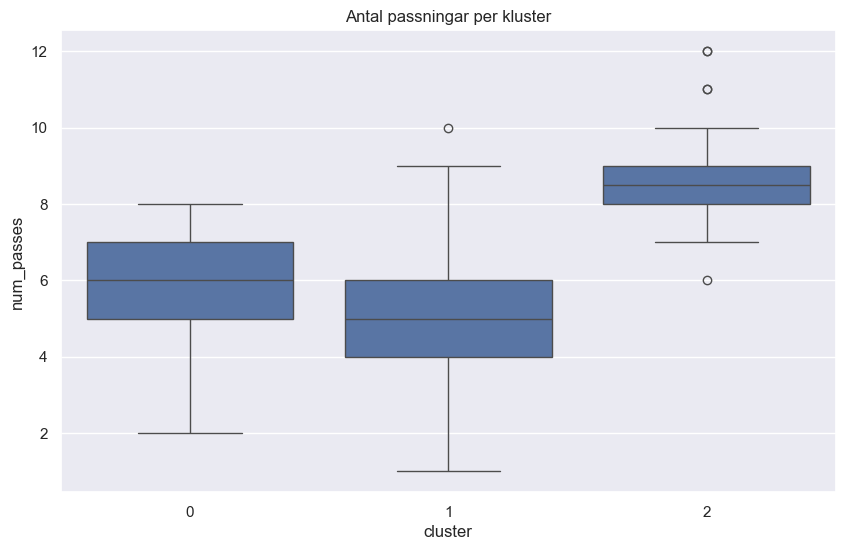

In [24]:
# OKLAR PLOTT, GÖR TYDLIGARE ANALYS

# Beräkna medelvärdet för varje egenskap per kluster
interpretation = features_df.groupby('cluster').mean()

# Snygga till presentationen
print(interpretation[['num_passes', 'duration', 'x_mean', 'y_std']].round(2))
# Skapa en boxplot för att se skillnaden i antal passningar mellan klustren
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='num_passes', data=features_df)
plt.title('Antal passningar per kluster')
plt.show()


In [ ]:
# Count passes within 10 seconds before each shot during the powerplay
pp_shots = data[(data['manpowersituation'] == 'powerPlay') &
                (data['eventname'].isin(['shot', 'goal']))].copy()

def count_recent_passes(row):
    mask = (data['gameid'] == row['gameid']) &\
           (data['compiledgametime'] < row['compiledgametime']) &\
           (data['compiledgametime'] > row['compiledgametime'] - 10) &\
           (data['eventname'] == 'pass') &\
           (data['manpowersituation'] == 'powerPlay')
    return mask.sum()

pp_shots['passes_before'] = pp_shots.apply(count_recent_passes, axis=1)
pp_shots.groupby('passes_before')['xg_allattempts'].agg(['mean', 'count']).head(15)

# Plot number of shots and their expected goal value against number of passes.
agg = pp_shots.groupby('passes_before')['xg_allattempts'].agg(['mean', 'count']).reset_index()
agg = agg[agg['count'] >= 10]  # Filter out low sample sizes

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(agg['passes_before'], agg['mean'], color='steelblue', label='Mean xG')
ax1.set_xlabel('Number of passes (within 10 sec)')
ax1.set_ylabel('Mean xG')
ax1.set_title('xG vs number of passes before shot (PP)')

ax2 = ax1.twinx()
ax2.plot(agg['passes_before'], agg['count'], color='orange', marker='o', label='Number of shots')
ax2.set_ylabel('Number of shots (n)')

plt.tight_layout()
plt.show()

Blue: Shots on goal by number of passes (0-7) and their mean Expected Goal value. Shot quality increases with more passes. <br>
Orange: Number of shots, most shots come after 3-4 passes. Few shots at 0-1 or 6+ passes. <br>
xG increases up to around 6 passes during the PP, then drops (only values with more than 10 observations shown).

## Plots where teams shot from in Powerplay

In [26]:
# 1. Sortera och förbered
df = sorted_data.sort_values(['gameid', 'compiledgametime']).copy()

# 2. Hitta starten på varje Powerplay
# Ett PP börjar när manpowersituation ändras till powerPlay
df['is_pp'] = (df['manpowersituation'] == 'powerPlay').astype(int)
df['pp_start'] = (df['is_pp'] == 1) & (df['is_pp'].shift(1) == 0)
df['pp_id'] = df.groupby('gameid')['pp_start'].cumsum()

# 3. Markera PP som delas av en periodpaus
# Vi tittar på varje pp_id och ser om det innehåller mer än ett period-nummer
pp_info = df[df['is_pp'] == 1].groupby(['gameid', 'pp_id']).agg({
    'period': ['min', 'max', 'nunique'],
    'eventname': lambda x: (x == 'goal').any() # Gjordes mål under detta PP?
}).reset_index()

pp_info.columns = ['gameid', 'pp_id', 'period_min', 'period_max', 'period_count', 'made_goal']

# Kategorisera
# 'Interrupted' = PP som spänner över mer än 1 period
# 'Continuous' = PP som spelas klart i samma period
pp_info['category'] = 'Continuous'
pp_info.loc[pp_info['period_count'] > 1, 'category'] = 'Interrupted'

# 4. Räkna ut andelen mål
resultat = pp_info.groupby('category')['made_goal'].mean() * 100

print("Andel Powerplay som resulterar i mål:")
print(resultat)

# Visa antal för att se underlaget
print("\nAntal Powerplay i varje kategori:")
print(pp_info['category'].value_counts())
print(df['manpowersituation'].value_counts())


Andel Powerplay som resulterar i mål:
category
Continuous     1.853486
Interrupted    0.000000
Name: made_goal, dtype: float64

Antal Powerplay i varje kategori:
category
Continuous     10197
Interrupted       11
Name: count, dtype: int64
manpowersituation
evenStrength    463668
powerPlay        59271
shortHanded      18863
Name: count, dtype: int64


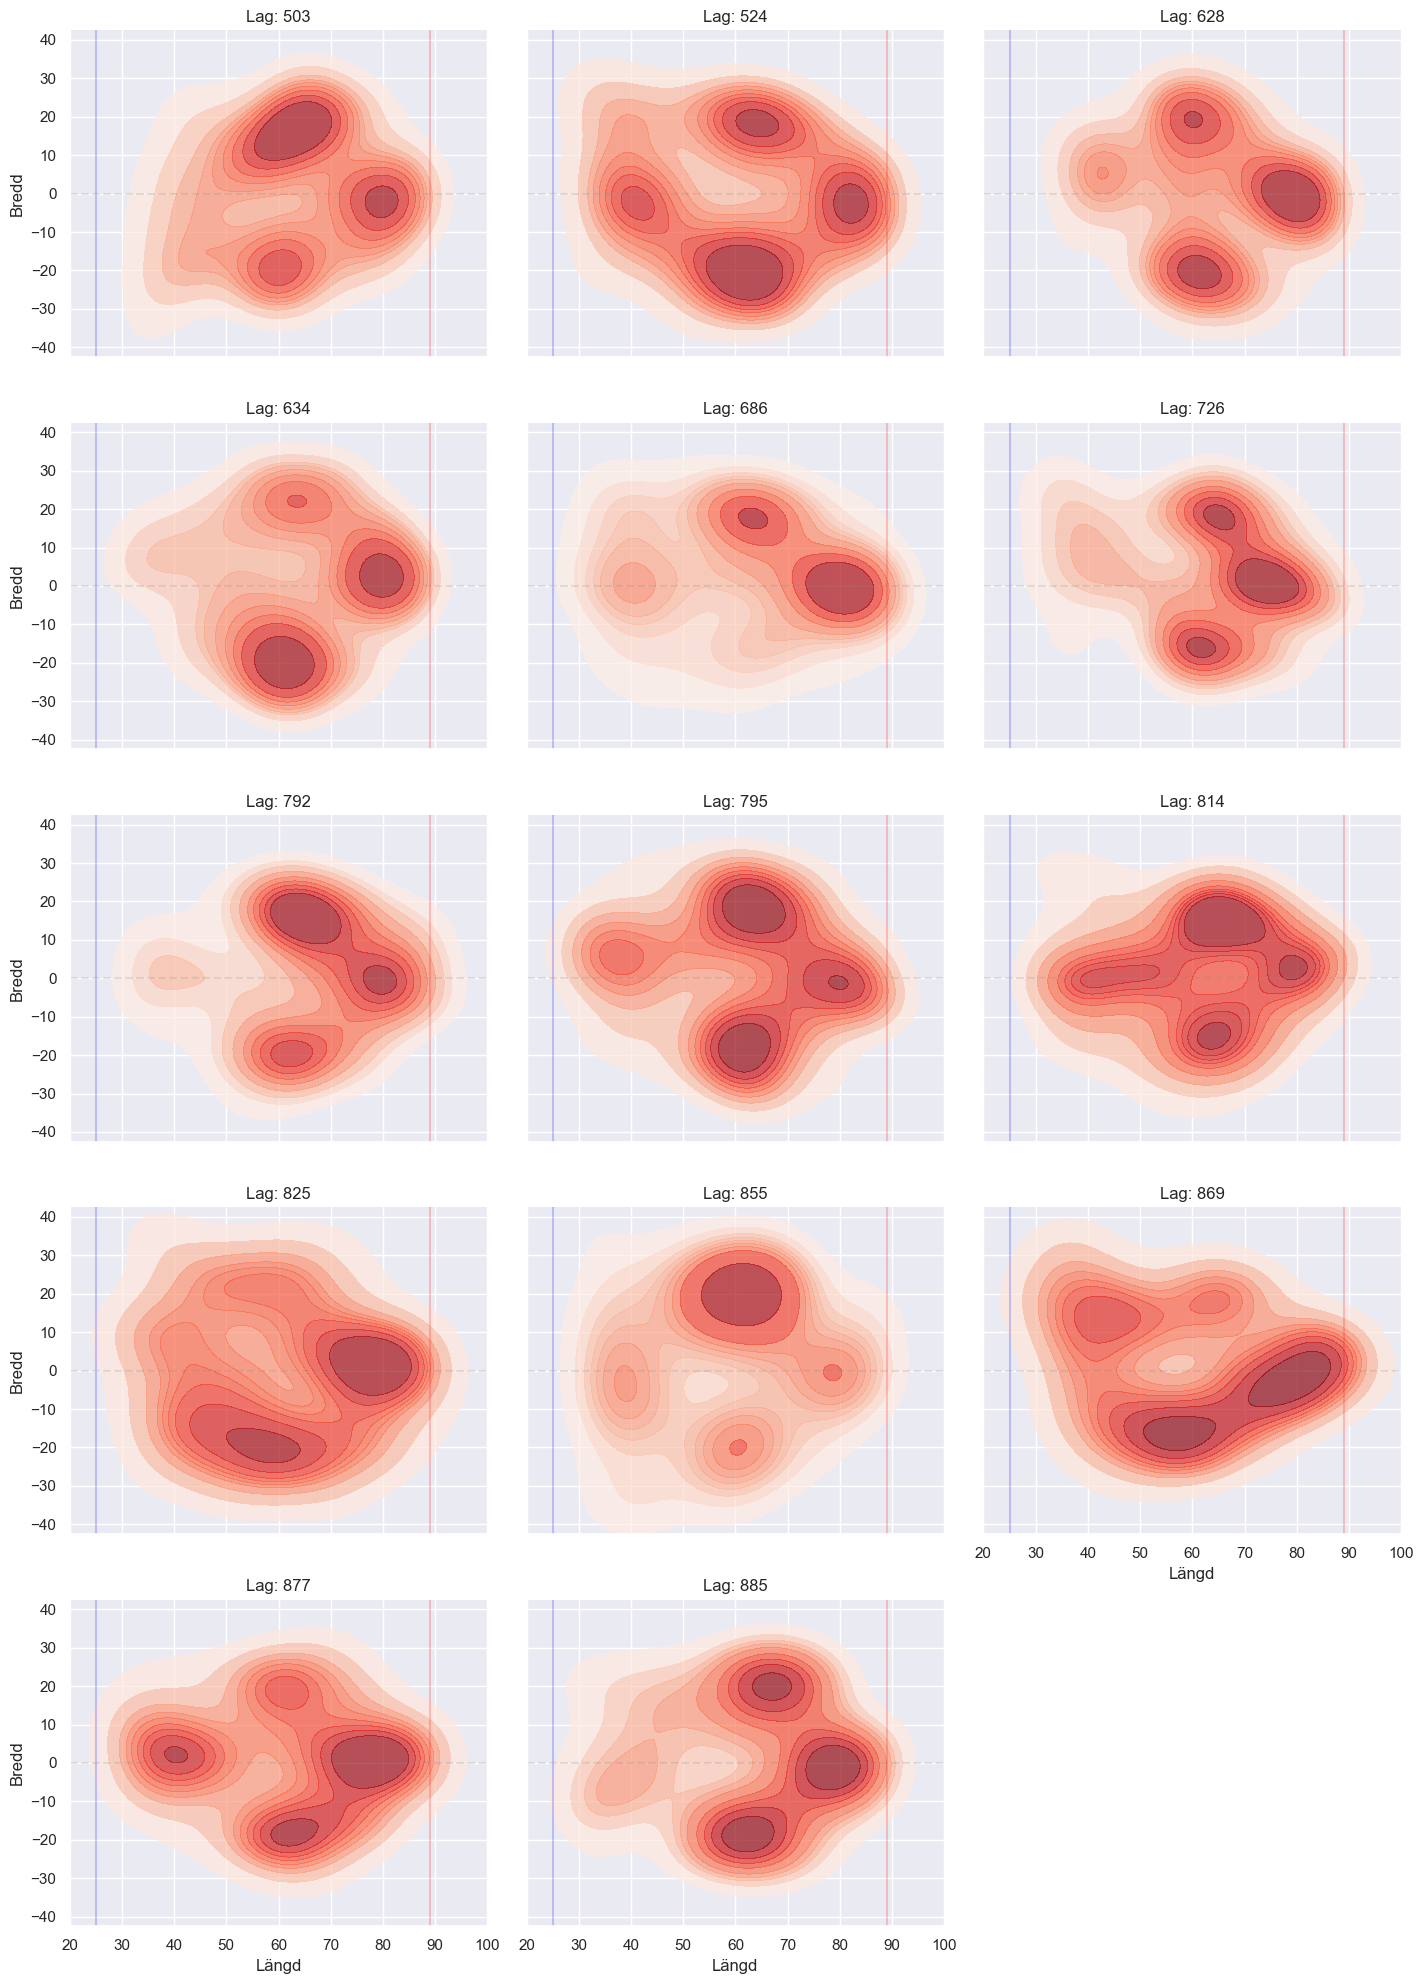

side    Höger  Vänster  Vänster_Procent
teamid                                 
855        65       91        58.333333
686       116      148        56.060606
726       114      135        54.216867
877        79       92        53.801170
634        67       76        53.146853
795        83       91        52.298851
814        90       97        51.871658
825        61       64        51.200000
869        97      101        51.010101
628        79       81        50.625000
885       102      104        50.485437
503       116      115        49.783550
792        72       71        49.650350
524       116       95        45.023697


In [27]:
# Filtrera fram alla skottförsök i Powerplay
# Vi inkluderar både mål och missade skott för att få ett större underlag
pp_shots = df[
    (df['manpowersituation'] == 'powerPlay') & 
    ((df['eventname'] == 'shot') | (df['eventname'] == 'goal'))
].copy()

# För att lättare se vänster/höger kan vi skapa en kolumn som mappar teamid till lagnamn 
# (Om du har en sådan lista, annars använder vi teamid)

# Vi väljer ut de lag som har flest skott för att få tydliga mönster
top_teams = pp_shots['teamid'].value_counts().index
filter_df = pp_shots[pp_shots['teamid'].isin(top_teams)]

# Skapa en grid av plots
g = sns.FacetGrid(filter_df, col="teamid", col_wrap=3, height=4, aspect=1.2)

# Rita rinken (symboliskt) på varje sub-plot
def draw_rink_mini(*args, **kwargs):
    plt.axvline(25, color='blue', alpha=0.2) # Blålinje
    plt.axvline(89, color='red', alpha=0.2)  # Mållinje
    plt.axhline(0, color='grey', linestyle='--', alpha=0.2)

g.map(draw_rink_mini)

# Lägg på en heatmap (KDE) för varje lag
g.map_dataframe(sns.kdeplot, x="xadjcoord", y="yadjcoord", 
                fill=True, cmap="Reds", alpha=0.7, thresh=0.1)

# Sätt gränser för anfallszon
g.set(xlim=(20, 100), ylim=(-42.5, 42.5))
g.set_axis_labels("Längd", "Bredd")
g.set_titles("Lag: {col_name}")

plt.tight_layout()
plt.show()


# Definiera sidor (y > 0 är ena sidan, y < 0 är andra)
pp_shots['side'] = pp_shots['yadjcoord'].apply(lambda y: 'Vänster' if y > 0 else 'Höger')

side_distribution = pp_shots.groupby(['teamid', 'side']).size().unstack(fill_value=0)
side_distribution['Vänster_Procent'] = (side_distribution['Vänster'] / (side_distribution['Vänster'] + side_distribution['Höger'])) * 100

print(side_distribution.sort_values(by='Vänster_Procent', ascending=False))

## Powerplay goals by period time

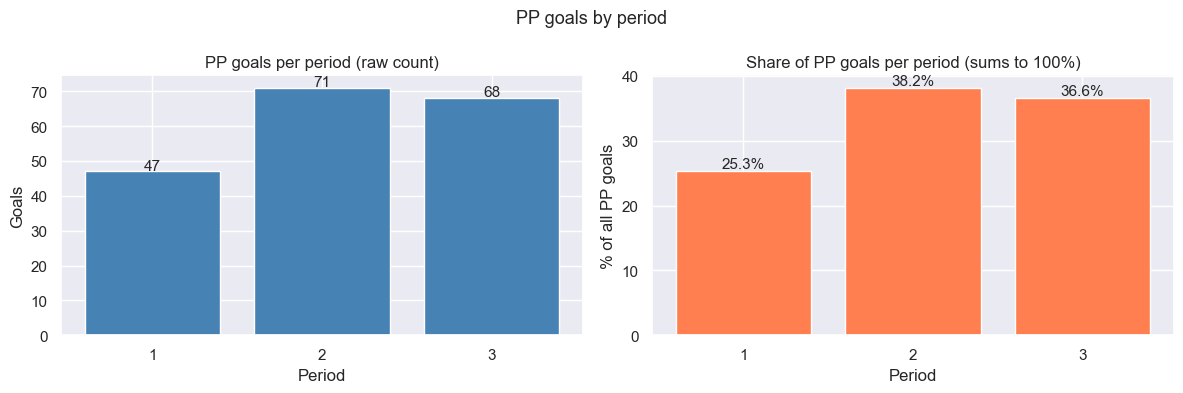

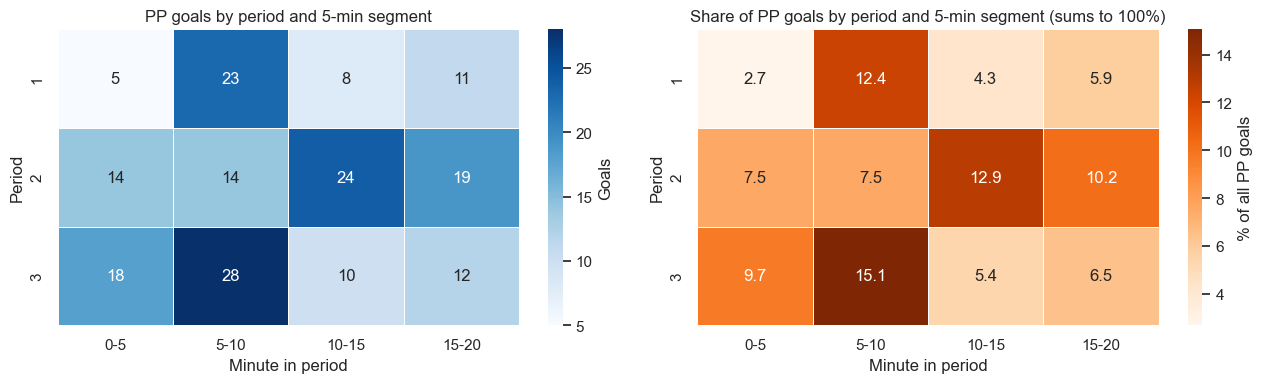

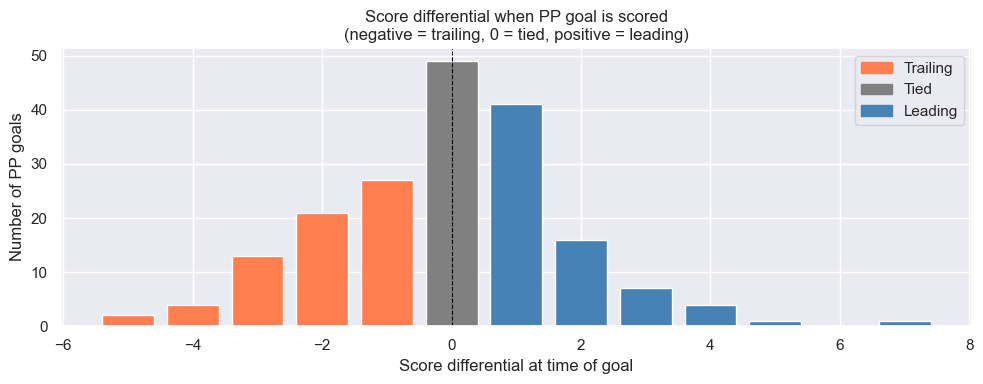

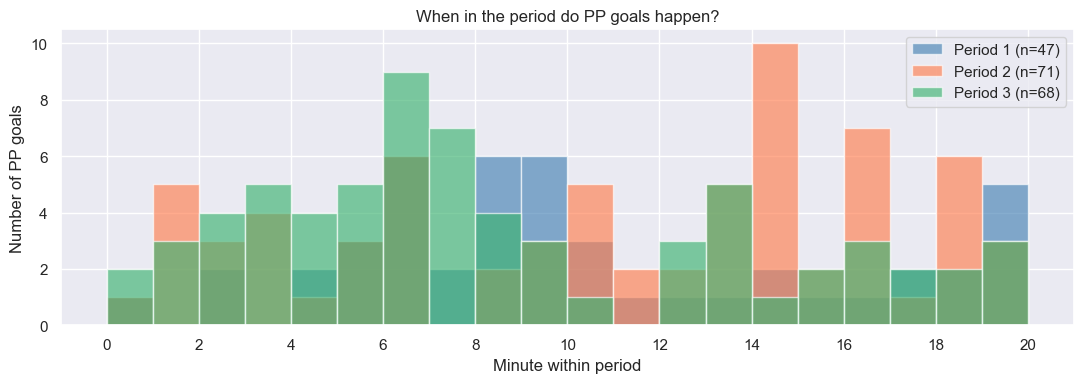

In [28]:
pp_goals = data[(data["manpowersituation"] == "powerPlay") &
                (data["eventname"] == "goal") &
                (data["period"].isin([1, 2, 3]))].copy()

pp_all = data[(data["manpowersituation"] == "powerPlay") &
              (data["period"].isin([1, 2, 3]))].copy()

# compiledgametime is cumulative across the full game
for df in [pp_goals, pp_all]:
    df["time_in_period_s"] = df["compiledgametime"] - (df["period"] - 1) * 1200
    df["minute_in_period"] = df["time_in_period_s"] / 60
    df["5min_bin"] = (df["minute_in_period"] // 5 * 5).clip(0, 15).astype(int)
    df["5min_label"] = df["5min_bin"].astype(str) + "-" + (df["5min_bin"] + 5).astype(str)

goals_per_period = pp_goals["period"].value_counts().sort_index()
share_per_period = goals_per_period / goals_per_period.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(goals_per_period.index, goals_per_period.values, color="steelblue", edgecolor="white")
axes[0].set_title("PP goals per period (raw count)")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Goals")
axes[0].set_xticks([1, 2, 3])
for i, v in zip(goals_per_period.index, goals_per_period.values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=11)

axes[1].bar(share_per_period.index, share_per_period.values, color="coral", edgecolor="white")
axes[1].set_title("Share of PP goals per period (sums to 100%)")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("% of all PP goals")
axes[1].set_xticks([1, 2, 3])
for i, v in zip(share_per_period.index, share_per_period.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11)

plt.suptitle("PP goals by period", fontsize=13)
plt.tight_layout()
plt.show()

bin_labels = ["0-5", "5-10", "10-15", "15-20"]
goal_matrix = pp_goals.groupby(["period", "5min_label"]).size().unstack(fill_value=0)
goal_matrix = goal_matrix.reindex(columns=bin_labels, fill_value=0)

event_matrix = pp_all.groupby(["period", "5min_label"]).size().unstack(fill_value=0)
event_matrix = event_matrix.reindex(columns=bin_labels, fill_value=0)
share_matrix = (goal_matrix / goal_matrix.values.sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(goal_matrix, annot=True, fmt="d", cmap="Blues",
            ax=axes[0], linewidths=0.5, cbar_kws={"label": "Goals"})
axes[0].set_title("PP goals by period and 5-min segment")
axes[0].set_xlabel("Minute in period")
axes[0].set_ylabel("Period")

sns.heatmap(share_matrix, annot=True, fmt=".1f", cmap="Oranges",
            ax=axes[1], linewidths=0.5, cbar_kws={"label": "% of all PP goals"})
axes[1].set_title("Share of PP goals by period and 5-min segment (sums to 100%)")
axes[1].set_xlabel("Minute in period")
axes[1].set_ylabel("Period")

plt.tight_layout()
plt.show()

score_counts = pp_goals["scoredifferential"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["coral" if x < 0 else "steelblue" if x > 0 else "gray" for x in score_counts.index]
ax.bar(score_counts.index, score_counts.values, color=colors, edgecolor="white")
ax.set_title("Score differential when PP goal is scored\n(negative = trailing, 0 = tied, positive = leading)")
ax.set_xlabel("Score differential at time of goal")
ax.set_ylabel("Number of PP goals")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="coral", label="Trailing"),
    Patch(color="gray", label="Tied"),
    Patch(color="steelblue", label="Leading")
])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
period_colors = {1: "steelblue", 2: "coral", 3: "mediumseagreen"}
for p in [1, 2, 3]:
    subset = pp_goals[pp_goals["period"] == p]["minute_in_period"]
    ax.hist(subset, bins=20, range=(0, 20), alpha=0.65,
            label=f"Period {p} (n={len(subset)})", color=period_colors[p], edgecolor="white")
ax.set_title("When in the period do PP goals happen?")
ax.set_xlabel("Minute within period")
ax.set_ylabel("Number of PP goals")
ax.set_xticks(range(0, 21, 2))
ax.legend()
plt.tight_layout()
plt.show()

## When does a powerplay become less effective?